In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [14]:
df = pd.read_csv("boston.csv")
df

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
0,0.00632,2.31,0.538,6.575,65.199997,4.0900,296,15.300000,396.899994,24.000000
1,0.02731,7.07,0.469,6.421,78.900002,4.9671,242,17.799999,396.899994,21.600000
2,0.02729,7.07,0.469,7.185,61.099998,4.9671,242,17.799999,392.829987,34.700001
3,0.03237,2.18,0.458,6.998,45.799999,6.0622,222,18.700001,394.630005,33.400002
4,0.06905,2.18,0.458,7.147,54.200001,6.0622,222,18.700001,396.899994,36.200001
...,...,...,...,...,...,...,...,...,...,...
501,0.06263,11.93,0.573,6.593,69.099998,2.4786,273,21.000000,391.989990,22.400000
502,0.04527,11.93,0.573,6.120,76.699997,2.2875,273,21.000000,396.899994,20.600000
503,0.06076,11.93,0.573,6.976,91.000000,2.1675,273,21.000000,396.899994,23.900000
504,0.10959,11.93,0.573,6.794,89.300003,2.3889,273,21.000000,393.450012,22.000000


In [15]:
df.size

5060

In [16]:
df.head(10)

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
0,0.00632,2.31,0.538,6.575,65.199997,4.0900,296,15.300000,396.899994,24.000000
1,0.02731,7.07,0.469,6.421,78.900002,4.9671,242,17.799999,396.899994,21.600000
2,0.02729,7.07,0.469,7.185,61.099998,4.9671,242,17.799999,392.829987,34.700001
3,0.03237,2.18,0.458,6.998,45.799999,6.0622,222,18.700001,394.630005,33.400002
4,0.06905,2.18,0.458,7.147,54.200001,6.0622,222,18.700001,396.899994,36.200001
5,0.02985,2.18,0.458,6.430,58.700001,6.0622,222,18.700001,394.119995,28.700001
6,0.08829,7.87,0.524,6.012,66.599998,5.5605,311,15.200000,395.600006,22.900000
7,0.14455,7.87,0.524,6.172,96.099998,5.9505,311,15.200000,396.899994,27.100000
8,0.21124,7.87,0.524,5.631,100.000000,6.0821,311,15.200000,386.630005,16.500000
9,0.17004,7.87,0.524,6.004,85.900002,6.5921,311,15.200000,386.709992,18.900000


In [17]:
df.tail(10)

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
496,0.28960,9.69,0.585,5.390,72.900002,2.7986,391,19.200001,396.899994,19.700001
497,0.26838,9.69,0.585,5.794,70.599998,2.8927,391,19.200001,396.899994,18.299999
498,0.23912,9.69,0.585,6.019,65.300003,2.4091,391,19.200001,396.899994,21.200001
499,0.17783,9.69,0.585,5.569,73.500000,2.3999,391,19.200001,395.769989,17.500000
500,0.22438,9.69,0.585,6.027,79.699997,2.4982,391,19.200001,396.899994,16.799999
501,0.06263,11.93,0.573,6.593,69.099998,2.4786,273,21.000000,391.989990,22.400000
502,0.04527,11.93,0.573,6.120,76.699997,2.2875,273,21.000000,396.899994,20.600000
503,0.06076,11.93,0.573,6.976,91.000000,2.1675,273,21.000000,396.899994,23.900000
504,0.10959,11.93,0.573,6.794,89.300003,2.3889,273,21.000000,393.450012,22.000000
505,0.04741,11.93,0.573,6.030,80.800003,2.5050,273,21.000000,396.899994,11.900000


In [18]:
df.isnull().sum()

CRIM     0
INDUS    0
NOX      0
RM       0
AGE      0
DIS      0
TAX      0
PT       0
B        0
MV       0
dtype: int64

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   CRIM    506 non-null    float64
 1   INDUS   506 non-null    float64
 2   NOX     506 non-null    float64
 3   RM      506 non-null    float64
 4   AGE     506 non-null    float64
 5   DIS     506 non-null    float64
 6   TAX     506 non-null    int64  
 7   PT      506 non-null    float64
 8   B       506 non-null    float64
 9   MV      506 non-null    float64
dtypes: float64(9), int64(1)
memory usage: 39.7 KB


In [20]:
df.describe()

,CRIM,INDUS,NOX,RM,AGE,DIS,TAX,PT,B,MV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674030,22.532806
std,8.601545,6.860353,0.115878,0.702617,28.148862,2.105710,168.537116,2.164946,91.294863,9.197104
min,0.006320,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,5.000000
25%,0.082045,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377487,17.025000
50%,0.256510,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440002,21.200001
75%,3.677083,18.100000,0.624000,6.623500,94.074999,5.188425,666.000000,20.200001,396.225006,25.000000
max,88.976196,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.899994,50.000000


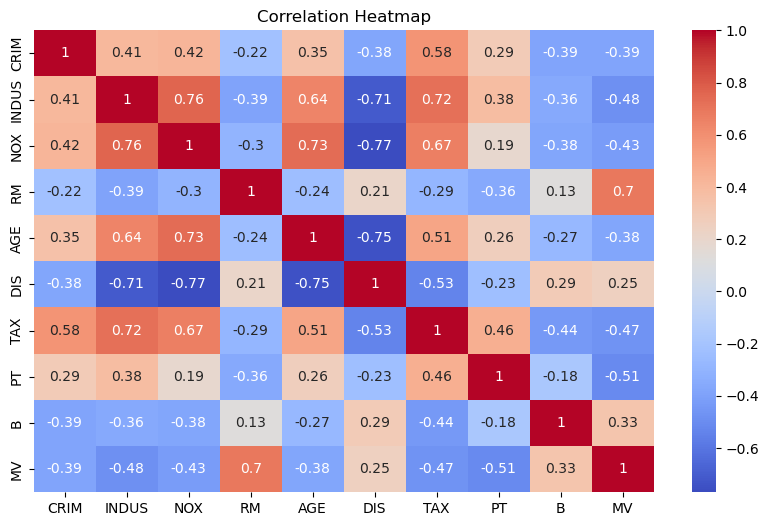

In [22]:
plt.figure(figsize = (10,6))
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

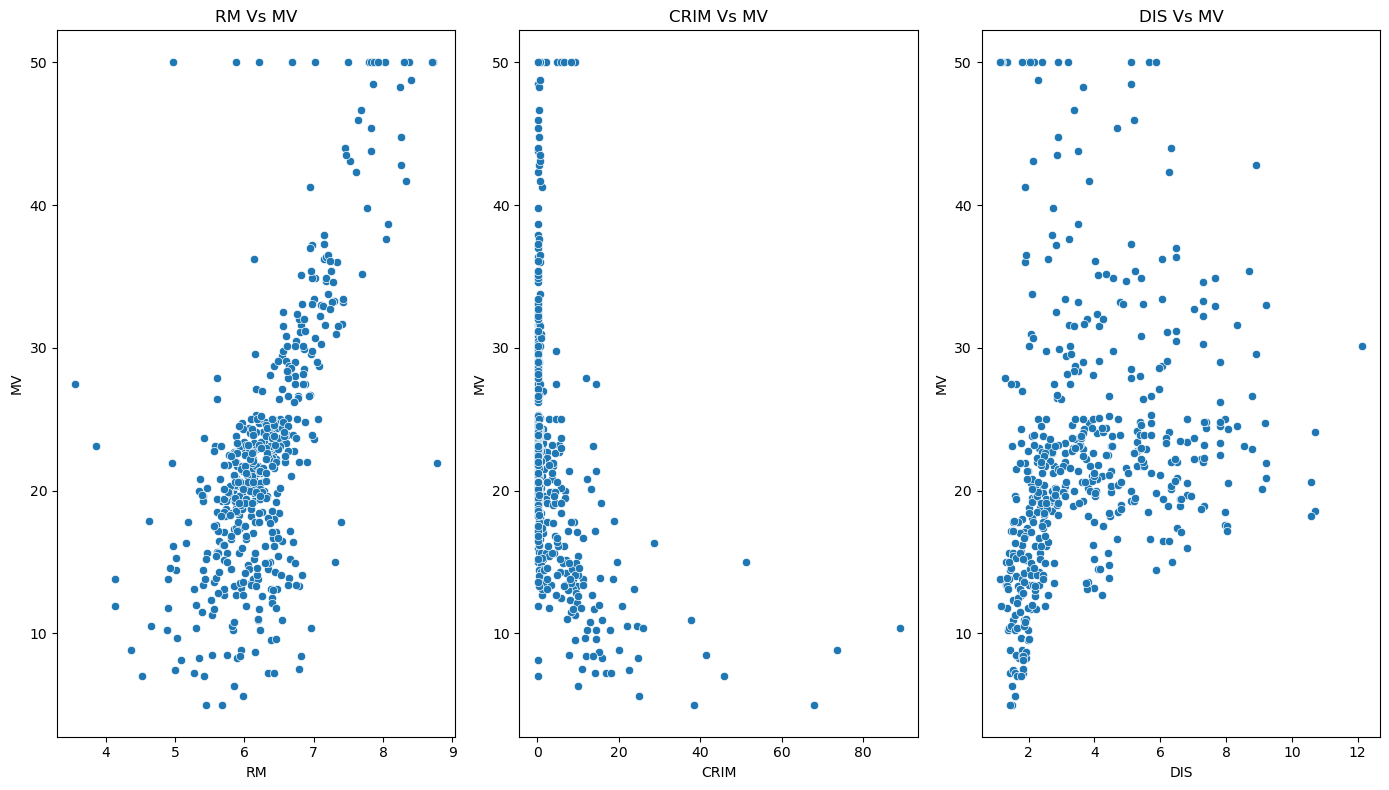

In [25]:
plt.figure(figsize = (14,8))
for i, col in enumerate(['RM','CRIM','DIS','NOX'][:3]):
    plt.subplot(1,3,i+1)
    sns.scatterplot(x = df[col], y = df['MV'])
    plt.title(f'{col} Vs MV')
plt.tight_layout()
plt.show()

In [27]:
X = df.drop('MV', axis = 1)
y = df['MV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [28]:
model = LinearRegression()
model.fit(X_train, y_train)
print("Intercept : ", model.intercept_)

coeff_df = pd.DataFrame({'Feature' :X.columns, 'Coefficient': model.coef_})
print("\nFeature coefficients : \n", coeff_df)


Intercept :  10.09059116865014

Feature coefficients : 
   Feature  Coefficient
0    CRIM    -0.121369
1   INDUS    -0.027280
2     NOX   -19.200402
3      RM     7.140508
4     AGE    -0.049303
5     DIS    -1.407873
6     TAX     0.000381
7      PT    -0.987416
8       B     0.016012


In [30]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nMean Squared Error : ", round(mse,2))
print("R2 score : ",round(r2,3))


Mean Squared Error :  32.62
R2 score :  0.555


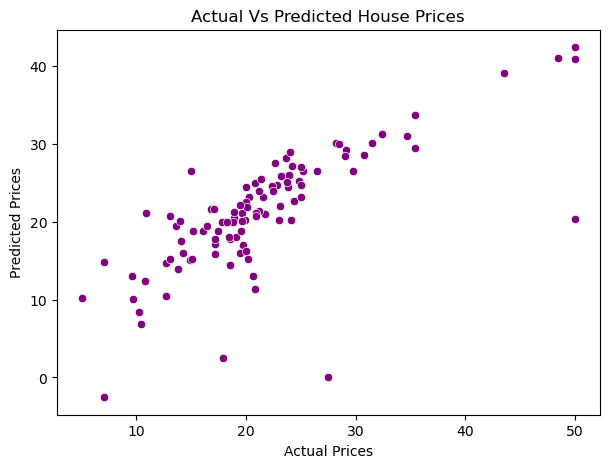

In [31]:
plt.figure(figsize = (7,5))
sns.scatterplot(x = y_test, y = y_pred, color = 'purple')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Vs Predicted House Prices")
plt.show()
           

C:\Users\bhand\AppData\Local\Temp\ipykernel_6240\3105354809.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x = "Coefficient", y = "Feature",


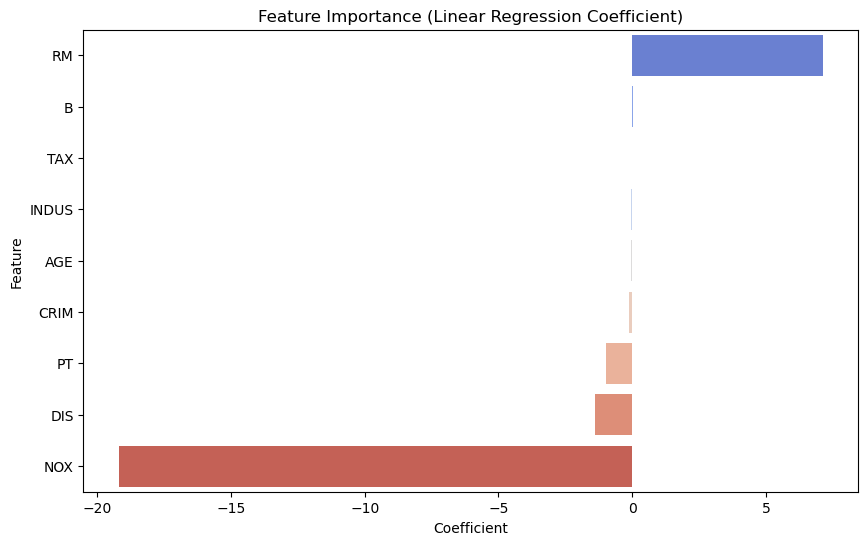

In [34]:
plt.figure(figsize = (10,6))
sns.barplot(x = "Coefficient", y = "Feature", 
            data = coeff_df.sort_values(by='Coefficient', ascending = False),palette = 'coolwarm')
plt.title("Feature Importance (Linear Regression Coefficient)")
plt.show()